# INTARIAN_PEPPER_ROOT Round 2 Dashboard

This notebook analyzes `INTARIAN_PEPPER_ROOT` using the Round 2 CSVs in `data/ROUND_2`.

It extracts the product-specific price and trade data, computes book and trade context features, then shows summary tables and the main graphs for:
- best bid / best ask and trades
- mid-price trend
- bid / ask ladder
- spreads
- level-3 depth
- imbalance
- volatility
- trade markout behavior


In [1]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'requirements.txt').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('Could not locate the repo root from the current working directory.')


REPO_ROOT = find_repo_root()
MPLCONFIGDIR = REPO_ROOT / '.mpl-cache'
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIGDIR))

SYMBOL = 'INTARIAN_PEPPER_ROOT'
ROUND_NAME = 'ROUND_2'
DATA_DIR = REPO_ROOT / 'data' / ROUND_NAME
PRICE_GLOB = 'prices_round_2_day_*.csv'
TRADE_GLOB = 'trades_round_2_day_*.csv'

plt.style.use('bmh')
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

print(f'Repo root: {REPO_ROOT}')
print(f'Data dir:   {DATA_DIR}')


Repo root: /Users/aditya/Documents/university_resource_files/prosperity_4/prosperity-4
Data dir:   /Users/aditya/Documents/university_resource_files/prosperity_4/prosperity-4/data/ROUND_2


In [2]:
def parse_day_from_filename(path: Path) -> int:
    return int(path.stem.split('_')[-1])


def load_price_data() -> pd.DataFrame:
    price_files = sorted(DATA_DIR.glob(PRICE_GLOB))
    if not price_files:
        raise FileNotFoundError(f'No price files found in {DATA_DIR}')

    frames: list[pd.DataFrame] = []
    for path in price_files:
        frame = pd.read_csv(path, sep=';')
        frame = frame[frame['product'] == SYMBOL].copy()
        for column in frame.columns:
            if column != 'product':
                frame[column] = pd.to_numeric(frame[column], errors='coerce')

        empty_book = frame['bid_price_1'].isna() & frame['ask_price_1'].isna() & (frame['mid_price'] == 0)
        frame.loc[empty_book, 'mid_price'] = np.nan

        frame['source_file'] = path.name
        frame['file_day'] = parse_day_from_filename(path)
        frames.append(frame)

    prices = pd.concat(frames, ignore_index=True).sort_values(['day', 'timestamp']).reset_index(drop=True)
    day_offset = prices['day'] - prices['day'].min()
    prices['global_ts'] = day_offset * 1_000_000 + prices['timestamp']

    prices['best_bid'] = prices['bid_price_1']
    prices['best_ask'] = prices['ask_price_1']
    prices['spread_1'] = prices['ask_price_1'] - prices['bid_price_1']
    prices['spread_2'] = prices['ask_price_2'] - prices['bid_price_2']
    prices['spread_3'] = prices['ask_price_3'] - prices['bid_price_3']
    prices['mid_from_quotes'] = (prices['bid_price_1'] + prices['ask_price_1']) / 2

    l1_total = prices['bid_volume_1'] + prices['ask_volume_1']
    l3_bid_depth = prices[['bid_volume_1', 'bid_volume_2', 'bid_volume_3']].fillna(0).sum(axis=1)
    l3_ask_depth = prices[['ask_volume_1', 'ask_volume_2', 'ask_volume_3']].fillna(0).sum(axis=1)
    l3_total = l3_bid_depth + l3_ask_depth

    prices['microprice_l1'] = (
        prices['ask_price_1'] * prices['bid_volume_1'] + prices['bid_price_1'] * prices['ask_volume_1']
    ) / l1_total.replace(0, np.nan)
    prices['imbalance_l1'] = (prices['bid_volume_1'] - prices['ask_volume_1']) / l1_total.replace(0, np.nan)
    prices['bid_depth_l3'] = l3_bid_depth
    prices['ask_depth_l3'] = l3_ask_depth
    prices['imbalance_l3'] = (l3_bid_depth - l3_ask_depth) / l3_total.replace(0, np.nan)
    prices['rolling_mid_100'] = prices['mid_price'].rolling(100, min_periods=20).mean()
    prices['rolling_mid_500'] = prices['mid_price'].rolling(500, min_periods=50).mean()
    prices['rolling_vol_100'] = prices['mid_price'].diff().rolling(100, min_periods=20).std()
    prices['mid_change_1'] = prices['mid_price'].diff()
    prices['mid_change_10'] = prices['mid_price'].diff(10)
    prices['mid_change_100'] = prices['mid_price'].diff(100)
    prices['session_progress'] = prices.groupby('day').cumcount() / prices.groupby('day')['timestamp'].transform('count')
    return prices


def load_trade_data() -> pd.DataFrame:
    trade_files = sorted(DATA_DIR.glob(TRADE_GLOB))
    if not trade_files:
        raise FileNotFoundError(f'No trade files found in {DATA_DIR}')

    frames: list[pd.DataFrame] = []
    for path in trade_files:
        frame = pd.read_csv(path, sep=';')
        frame = frame[frame['symbol'] == SYMBOL].copy()
        if frame.empty:
            continue
        frame['day'] = parse_day_from_filename(path)
        for column in ['timestamp', 'price', 'quantity']:
            frame[column] = pd.to_numeric(frame[column], errors='coerce')
        frame['source_file'] = path.name
        frames.append(frame)

    if not frames:
        return pd.DataFrame(columns=['timestamp', 'buyer', 'seller', 'symbol', 'currency', 'price', 'quantity', 'day'])

    trades = pd.concat(frames, ignore_index=True).sort_values(['day', 'timestamp']).reset_index(drop=True)
    day_offset = trades['day'] - trades['day'].min()
    trades['global_ts'] = day_offset * 1_000_000 + trades['timestamp']
    trades['notional'] = trades['price'] * trades['quantity']
    return trades


def build_trade_context(prices: pd.DataFrame, trades: pd.DataFrame) -> pd.DataFrame:
    if trades.empty:
        return trades.copy()

    quote_context = prices[
        [
            'global_ts',
            'day',
            'timestamp',
            'mid_price',
            'microprice_l1',
            'best_bid',
            'best_ask',
            'spread_1',
            'imbalance_l1',
            'imbalance_l3',
        ]
    ].sort_values('global_ts')
    future_context = prices[['global_ts', 'mid_price']].rename(columns={'mid_price': 'future_mid_10'}).copy()
    future_context['global_ts'] = future_context['global_ts'] - 1_000

    trade_context = pd.merge_asof(
        trades.sort_values('global_ts'),
        quote_context,
        on='global_ts',
        direction='backward',
    )
    trade_context = pd.merge_asof(
        trade_context.sort_values('global_ts'),
        future_context.sort_values('global_ts'),
        on='global_ts',
        direction='forward',
    )

    trade_context = trade_context.rename(columns={'day_x': 'day_trade', 'day_y': 'day_quote', 'timestamp_x': 'timestamp_trade', 'timestamp_y': 'timestamp_quote'})
    trade_context['trade_vs_mid'] = trade_context['price'] - trade_context['mid_price']
    trade_context['trade_vs_microprice'] = trade_context['price'] - trade_context['microprice_l1']
    trade_context['trade_vs_bid'] = trade_context['price'] - trade_context['best_bid']
    trade_context['trade_vs_ask'] = trade_context['price'] - trade_context['best_ask']
    trade_context['markout_10_ticks'] = trade_context['future_mid_10'] - trade_context['price']
    return trade_context


def build_overview(prices: pd.DataFrame, trades: pd.DataFrame, trade_context: pd.DataFrame) -> pd.DataFrame:
    start_mid = prices['mid_price'].dropna().iloc[0]
    end_mid = prices['mid_price'].dropna().iloc[-1]

    return pd.DataFrame(
        {
            'metric': [
                'Quote rows',
                'Trade rows',
                'Days covered',
                'Start mid',
                'End mid',
                'Net mid move',
                'Median best spread',
                'Mean best spread',
                'Median level-3 bid depth',
                'Median level-3 ask depth',
                'Mean L1 imbalance',
                'Mean L3 imbalance',
                'Mid autocorr lag 1',
                'Mid autocorr lag 10',
                'Share of positive 1-step mid moves',
                'Share of positive 10-step mid moves',
                'Trade VWAP',
                'Mean trade size',
                'Mean trade vs mid',
                'Mean trade vs microprice',
                'Mean 10-tick markout after trade',
            ],
            'value': [
                len(prices),
                len(trades),
                prices['day'].nunique(),
                start_mid,
                end_mid,
                end_mid - start_mid,
                prices['spread_1'].median(),
                prices['spread_1'].mean(),
                prices['bid_depth_l3'].median(),
                prices['ask_depth_l3'].median(),
                prices['imbalance_l1'].mean(),
                prices['imbalance_l3'].mean(),
                prices['mid_price'].autocorr(1),
                prices['mid_price'].autocorr(10),
                (prices['mid_change_1'] > 0).mean(),
                (prices['mid_change_10'] > 0).mean(),
                trades['notional'].sum() / trades['quantity'].sum() if not trades.empty else np.nan,
                trades['quantity'].mean() if not trades.empty else np.nan,
                trade_context['trade_vs_mid'].mean() if not trade_context.empty else np.nan,
                trade_context['trade_vs_microprice'].mean() if not trade_context.empty else np.nan,
                trade_context['markout_10_ticks'].mean() if not trade_context.empty else np.nan,
            ],
        }
    )


In [3]:
prices = load_price_data()
trades = load_trade_data()
trade_context = build_trade_context(prices, trades)
overview = build_overview(prices, trades, trade_context)

display(Markdown(f'## {SYMBOL} analysis for {ROUND_NAME}'))
display(overview)

display(Markdown('### Latest quote snapshots'))
display(
    prices[
        [
            'day',
            'timestamp',
            'best_bid',
            'bid_volume_1',
            'best_ask',
            'ask_volume_1',
            'mid_price',
            'spread_1',
            'bid_depth_l3',
            'ask_depth_l3',
            'imbalance_l1',
        ]
    ].tail(12)
)

display(Markdown('### Largest trades'))
display(
    trades[['day', 'timestamp', 'price', 'quantity', 'notional']]
    .sort_values(['quantity', 'notional'], ascending=[False, False])
    .head(12)
)


## INTARIAN_PEPPER_ROOT analysis for ROUND_2

,metric,value
0,Quote rows,"30,000.00"
1,Trade rows,996.00
2,Days covered,3.00
3,Start mid,"11,001.50"
4,End mid,"13,999.50"
5,Net mid move,"2,998.00"
6,Median best spread,14.00
7,Mean best spread,14.12
8,Median level-3 bid depth,27.00
9,Median level-3 ask depth,27.00


### Latest quote snapshots

,day,timestamp,best_bid,bid_volume_1,best_ask,ask_volume_1,mid_price,spread_1,bid_depth_l3,ask_depth_l3,imbalance_l1
29988,1,998800,"13,991.00",12.00,"14,006.00",12.00,"13,998.50",15.00,37.00,37.00,0.00
29989,1,998900,"13,991.00",10.00,"14,010.00",20.00,"14,000.50",19.00,30.00,20.00,-0.33
29990,1,999000,"13,992.00",10.00,"14,006.00",10.00,"13,999.00",14.00,25.00,25.00,0.00
29991,1,999100,"13,992.00",9.00,"14,007.00",9.00,"13,999.50",15.00,9.00,32.00,0.00
29992,1,999200,"13,992.00",12.00,"14,007.00",12.00,"13,999.50",15.00,30.00,30.00,0.00
29993,1,999300,"13,992.00",9.00,"14,007.00",9.00,"13,999.50",15.00,9.00,29.00,0.00
29994,1,999400,"13,992.00",12.00,"14,007.00",12.00,"13,999.50",15.00,27.00,27.00,0.00
29995,1,999500,"13,989.00",24.00,"14,007.00",9.00,"13,998.00",18.00,24.00,33.00,0.45
29996,1,999600,"13,992.00",12.00,"14,007.00",12.00,"13,999.50",15.00,35.00,35.00,0.00
29997,1,999700,"13,992.00",11.00,"14,007.00",11.00,"13,999.50",15.00,34.00,11.00,0.00


### Largest trades

,day,timestamp,price,quantity,notional
971,1,936600,"13,932.00",8,"111,456.00"
956,1,898100,"13,893.00",8,"111,144.00"
934,1,840900,"13,836.00",8,"110,688.00"
899,1,742000,"13,737.00",8,"109,896.00"
853,1,612300,"13,608.00",8,"108,864.00"
834,1,556700,"13,552.00",8,"108,416.00"
814,1,486200,"13,490.00",8,"107,920.00"
815,1,486700,"13,482.00",8,"107,856.00"
790,1,432100,"13,428.00",8,"107,424.00"
781,1,401000,"13,396.00",8,"107,168.00"


In [4]:
start_mid = prices['mid_price'].dropna().iloc[0]
end_mid = prices['mid_price'].dropna().iloc[-1]
median_spread = prices['spread_1'].median()
mean_imbalance = prices['imbalance_l1'].mean()
up_move_1 = (prices['mid_change_1'] > 0).mean()
up_move_10 = (prices['mid_change_10'] > 0).mean()
autocorr_10 = prices['mid_price'].autocorr(10)
trade_bias_mid = trade_context['trade_vs_mid'].mean() if not trade_context.empty else np.nan
markout_mean = trade_context['markout_10_ticks'].mean() if not trade_context.empty else np.nan

notes = [
    '## Market Notes',
    '',
    f'- The mid-price trends strongly upward across Round 2, from **{start_mid:.1f}** to **{end_mid:.1f}**.',
    f'- Median level-1 spread is **{median_spread:.1f}** ticks, so the book remains usable for market making.',
    f'- Mean level-1 imbalance is **{mean_imbalance:.3f}**, which tells us whether top-of-book pressure is persistently one-sided.',
    f'- Up moves account for **{up_move_1:.1%}** of 1-step moves and **{up_move_10:.1%}** of 10-step moves.',
    f'- Lag-10 mid autocorrelation is **{autocorr_10:.3f}**, a quick read on trend persistence.',
]

if not np.isnan(trade_bias_mid):
    notes.append(f'- Trades print **{trade_bias_mid:.2f}** ticks away from current mid on average.')
if not np.isnan(markout_mean):
    notes.append(f'- Average 10-tick markout after a trade is **{markout_mean:.2f}** ticks.')

display(Markdown('\n'.join(notes)))


## Market Notes

- The mid-price trends strongly upward across Round 2, from **11001.5** to **13999.5**.
- Median level-1 spread is **14.0** ticks, so the book remains usable for market making.
- Mean level-1 imbalance is **0.000**, which tells us whether top-of-book pressure is persistently one-sided.
- Up moves account for **36.9%** of 1-step moves and **71.5%** of 10-step moves.
- Lag-10 mid autocorrelation is **1.000**, a quick read on trend persistence.
- Trades print **0.05** ticks away from current mid on average.
- Average 10-tick markout after a trade is **0.86** ticks.

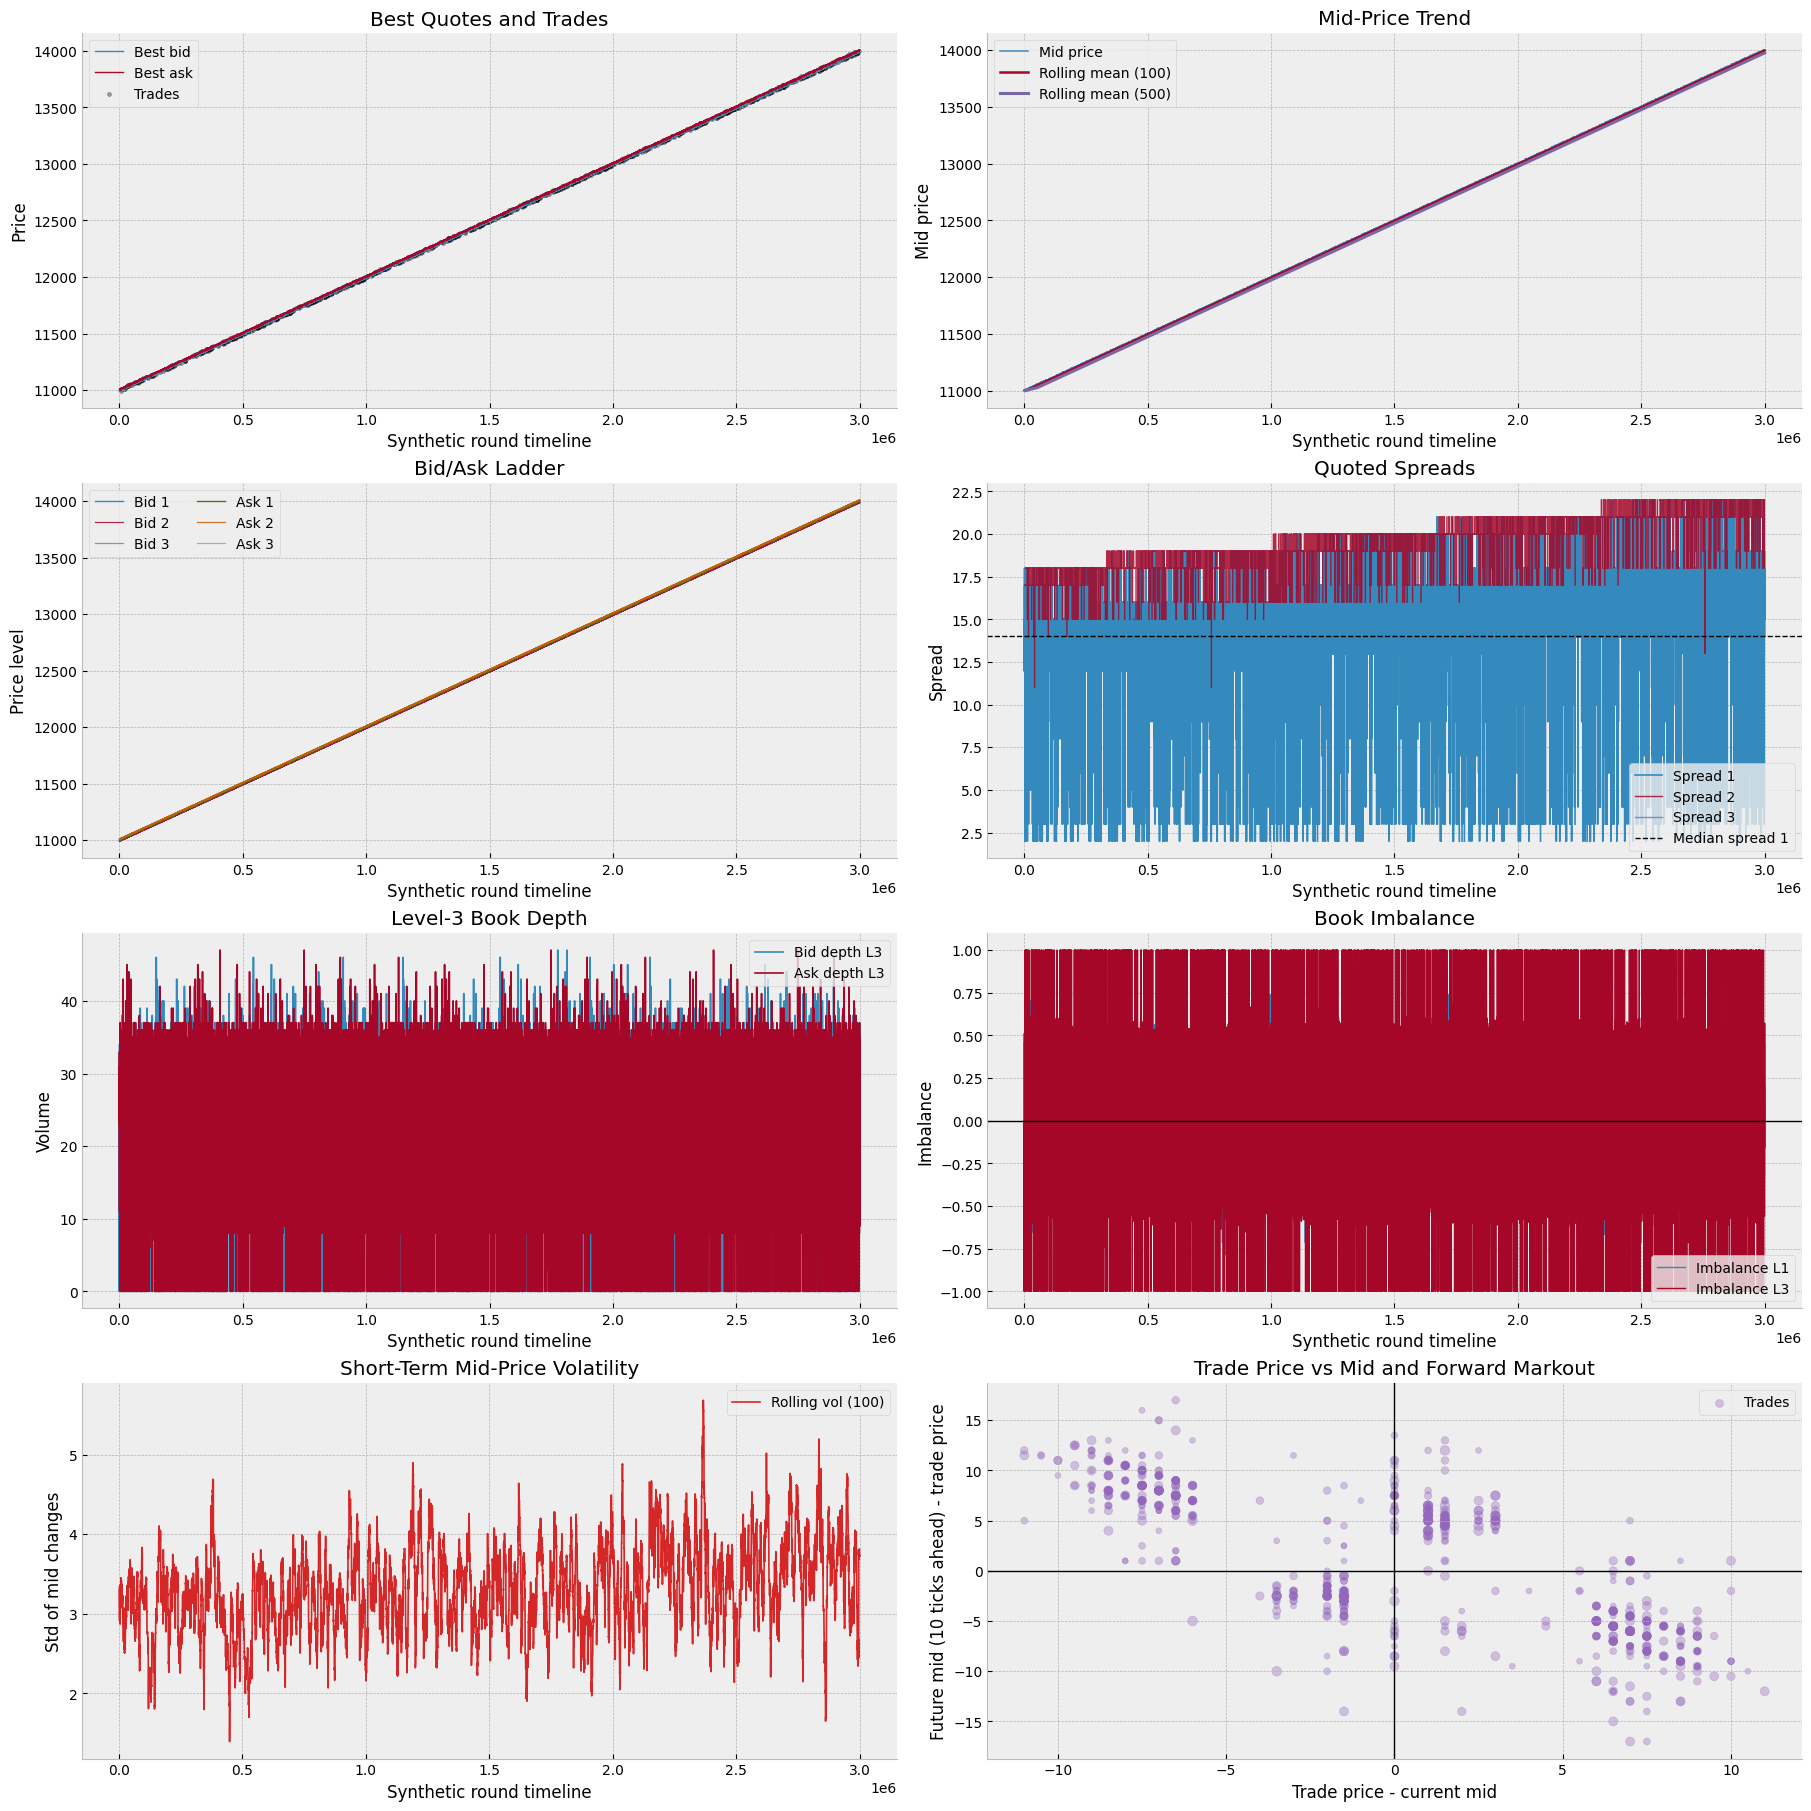

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(18, 18), constrained_layout=True)

axes[0, 0].plot(prices['global_ts'], prices['best_bid'], label='Best bid', linewidth=1.0)
axes[0, 0].plot(prices['global_ts'], prices['best_ask'], label='Best ask', linewidth=1.0)
if not trades.empty:
    axes[0, 0].scatter(trades['global_ts'], trades['price'], s=8, alpha=0.35, color='black', label='Trades')
axes[0, 0].set_title('Best Quotes and Trades')
axes[0, 0].set_xlabel('Synthetic round timeline')
axes[0, 0].set_ylabel('Price')
axes[0, 0].legend()

axes[0, 1].plot(prices['global_ts'], prices['mid_price'], label='Mid price', linewidth=1.1)
axes[0, 1].plot(prices['global_ts'], prices['rolling_mid_100'], label='Rolling mean (100)', linewidth=1.8)
axes[0, 1].plot(prices['global_ts'], prices['rolling_mid_500'], label='Rolling mean (500)', linewidth=2.2)
axes[0, 1].set_title('Mid-Price Trend')
axes[0, 1].set_xlabel('Synthetic round timeline')
axes[0, 1].set_ylabel('Mid price')
axes[0, 1].legend()

axes[1, 0].plot(prices['global_ts'], prices['bid_price_1'], label='Bid 1', linewidth=1.0)
axes[1, 0].plot(prices['global_ts'], prices['bid_price_2'], label='Bid 2', linewidth=0.9, alpha=0.85)
axes[1, 0].plot(prices['global_ts'], prices['bid_price_3'], label='Bid 3', linewidth=0.9, alpha=0.75)
axes[1, 0].plot(prices['global_ts'], prices['ask_price_1'], label='Ask 1', linewidth=1.0)
axes[1, 0].plot(prices['global_ts'], prices['ask_price_2'], label='Ask 2', linewidth=0.9, alpha=0.85)
axes[1, 0].plot(prices['global_ts'], prices['ask_price_3'], label='Ask 3', linewidth=0.9, alpha=0.75)
axes[1, 0].set_title('Bid/Ask Ladder')
axes[1, 0].set_xlabel('Synthetic round timeline')
axes[1, 0].set_ylabel('Price level')
axes[1, 0].legend(ncol=2)

axes[1, 1].plot(prices['global_ts'], prices['spread_1'], label='Spread 1', linewidth=1.2)
axes[1, 1].plot(prices['global_ts'], prices['spread_2'], label='Spread 2', linewidth=1.0, alpha=0.85)
axes[1, 1].plot(prices['global_ts'], prices['spread_3'], label='Spread 3', linewidth=1.0, alpha=0.75)
axes[1, 1].axhline(prices['spread_1'].median(), color='black', linestyle='--', linewidth=1, label='Median spread 1')
axes[1, 1].set_title('Quoted Spreads')
axes[1, 1].set_xlabel('Synthetic round timeline')
axes[1, 1].set_ylabel('Spread')
axes[1, 1].legend()

axes[2, 0].plot(prices['global_ts'], prices['bid_depth_l3'], label='Bid depth L3', linewidth=1.2)
axes[2, 0].plot(prices['global_ts'], prices['ask_depth_l3'], label='Ask depth L3', linewidth=1.2)
axes[2, 0].set_title('Level-3 Book Depth')
axes[2, 0].set_xlabel('Synthetic round timeline')
axes[2, 0].set_ylabel('Volume')
axes[2, 0].legend()

axes[2, 1].plot(prices['global_ts'], prices['imbalance_l1'], label='Imbalance L1', linewidth=1.0)
axes[2, 1].plot(prices['global_ts'], prices['imbalance_l3'], label='Imbalance L3', linewidth=1.0)
axes[2, 1].axhline(0, color='black', linewidth=1)
axes[2, 1].set_title('Book Imbalance')
axes[2, 1].set_xlabel('Synthetic round timeline')
axes[2, 1].set_ylabel('Imbalance')
axes[2, 1].legend()

axes[3, 0].plot(prices['global_ts'], prices['rolling_vol_100'], color='tab:red', linewidth=1.2, label='Rolling vol (100)')
axes[3, 0].set_title('Short-Term Mid-Price Volatility')
axes[3, 0].set_xlabel('Synthetic round timeline')
axes[3, 0].set_ylabel('Std of mid changes')
axes[3, 0].legend()

if not trade_context.empty:
    axes[3, 1].scatter(
        trade_context['trade_vs_mid'],
        trade_context['markout_10_ticks'],
        s=np.clip(trade_context['quantity'] * 6, 10, 120),
        alpha=0.35,
        color='tab:purple',
        label='Trades',
    )
    axes[3, 1].axhline(0, color='black', linewidth=1)
    axes[3, 1].axvline(0, color='black', linewidth=1)
    axes[3, 1].set_title('Trade Price vs Mid and Forward Markout')
    axes[3, 1].set_xlabel('Trade price - current mid')
    axes[3, 1].set_ylabel('Future mid (10 ticks ahead) - trade price')
    axes[3, 1].legend()
else:
    axes[3, 1].text(0.5, 0.5, 'No trades available', ha='center', va='center')
    axes[3, 1].set_title('Trade Markout')
    axes[3, 1].set_axis_off()

plt.show()


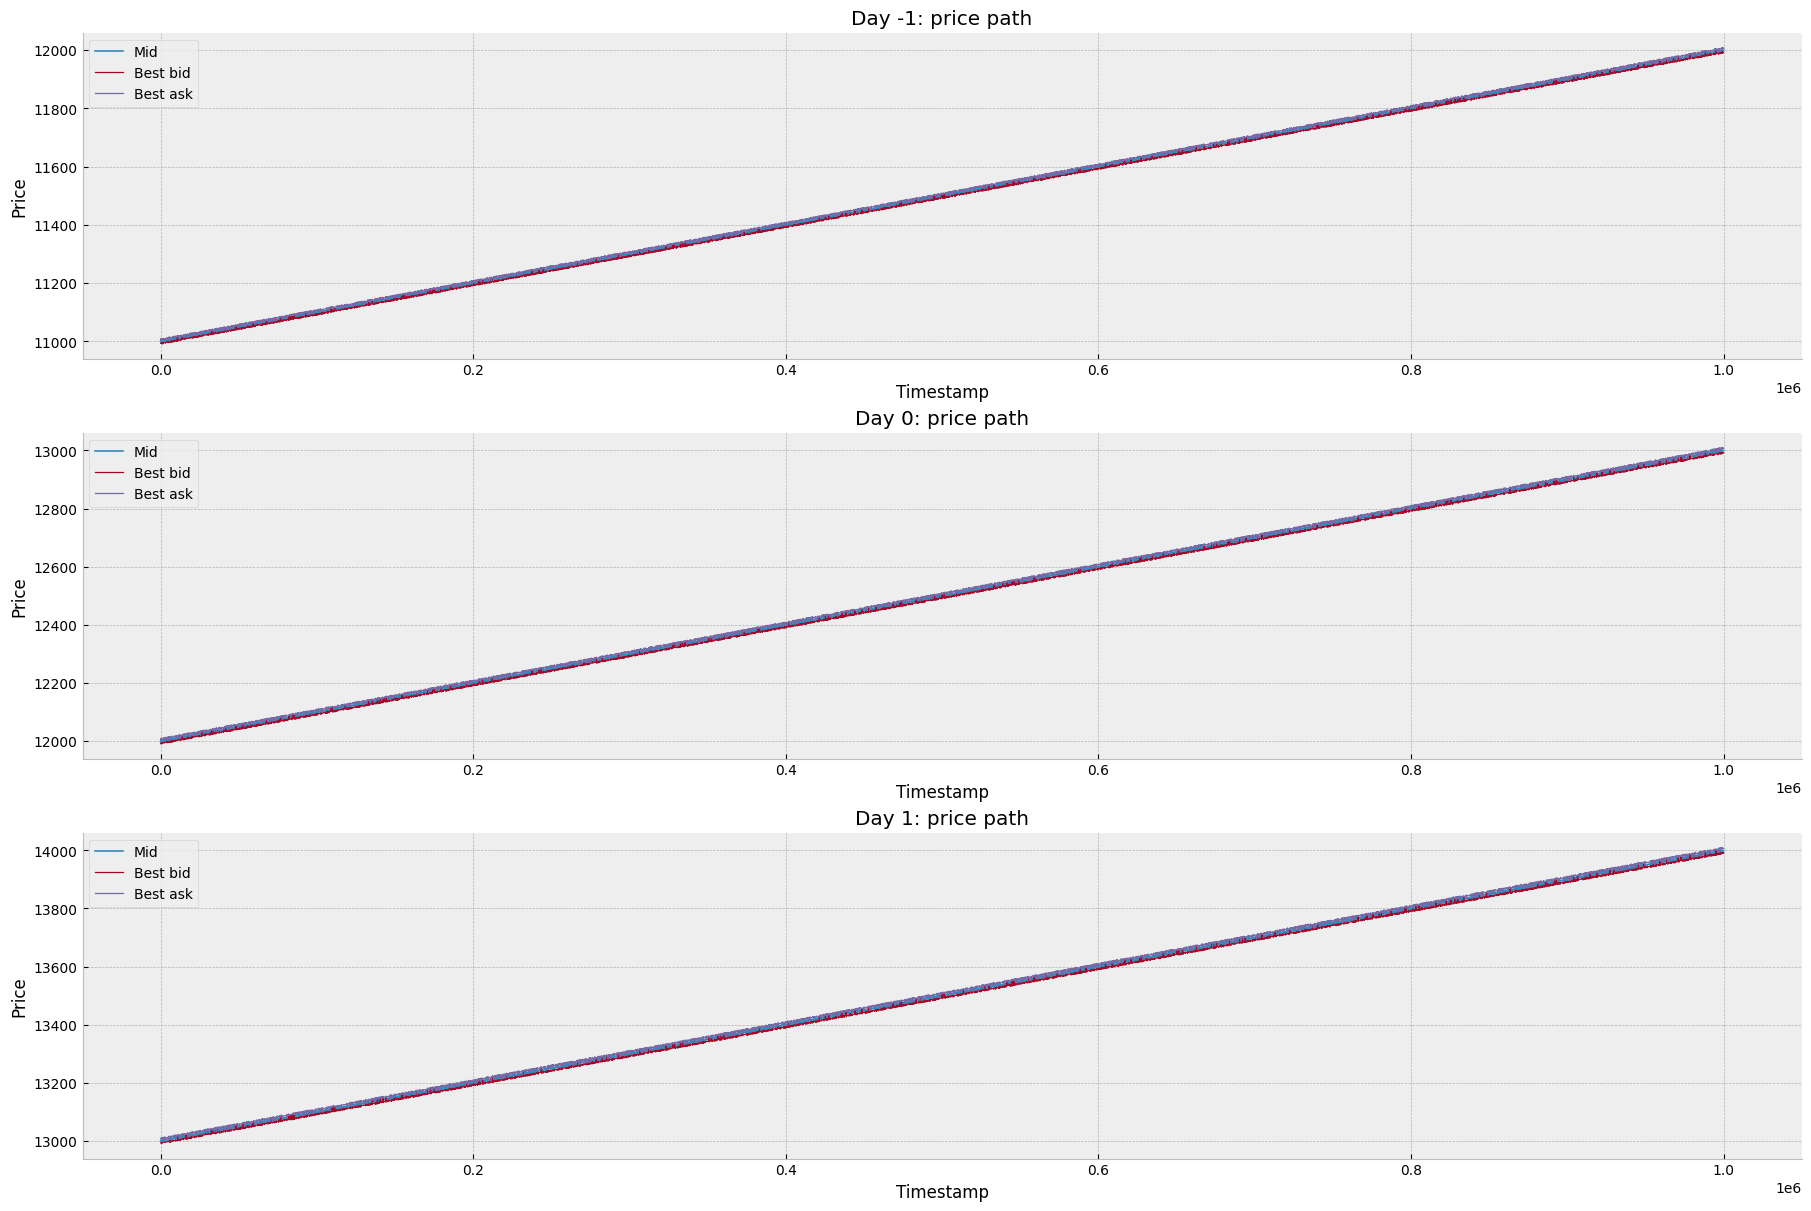

In [6]:
unique_days = sorted(prices['day'].dropna().unique())
fig, day_axes = plt.subplots(len(unique_days), 1, figsize=(18, 4 * len(unique_days)), sharex=False, constrained_layout=True)
if len(unique_days) == 1:
    day_axes = [day_axes]

for axis, (day, frame) in zip(day_axes, prices.groupby('day', sort=True)):
    axis.plot(frame['timestamp'], frame['mid_price'], label='Mid', linewidth=1.2)
    axis.plot(frame['timestamp'], frame['best_bid'], label='Best bid', linewidth=0.9)
    axis.plot(frame['timestamp'], frame['best_ask'], label='Best ask', linewidth=0.9)
    axis.set_title(f'Day {day}: price path')
    axis.set_xlabel('Timestamp')
    axis.set_ylabel('Price')
    axis.legend()

plt.show()
